In [1]:

import sys
sys.path.append('../')
from utils_v2 import *

/home/kai/miniconda3/envs/tensorflow/lib/python3.10/site-packages/qiskit_dynamics/dispatch/backends/jax.py:34: UserWarning: The functionality in the perturbation module of Qiskit Dynamics requires a JAX version <= 0.4.6, due to a bug in JAX versions > 0.4.6. For versions 0.4.4, 0.4.5, and 0.4.6, using the perturbation module functionality requires setting os.environ['JAX_JIT_PJIT_API_MERGE'] = '0' before importing JAX or Dynamics.
  warnings.warn(


In [2]:
ql = 20
max_ol = 60

system = FluxoniumOscillatorSystem(
    computaional_states = '1,2',
    EJ = 2.33,
    EC = 0.69,
    EL = 0.12,
    Er = 7.16518677 ,
    qubit_level = ql,
    osc_level = max_ol,
    g_strength = 0.18,
    products_to_keep=[[ql,ol] for ql in [0,1,2,3] for ol in range(max_ol)] 
    )
tlist = np.linspace(0,20,20)

In [3]:

results = system.run_mesolve_parrallel(
    initial_states=[ system.truncate_function(qutip.basis(system.hilbertspace.dimension, i)) for i in range(4)],
    tlist = tlist,
    drive_terms=[
        DriveTerm(
            driven_op=system.a_trunc + system.a_trunc.dag(),
            pulse_shape_func=square_pulse_with_rise_fall,
            pulse_shape_args={
                'w_d': 7.16475,
                'amp': 0.0025,
                't_square': 10000
            }
        )],
    e_ops=[
            system.a_trunc,
            system.a_trunc.dag()*system.a_trunc
        ],
)




 /home/kai/miniconda3/envs/tensorflow/lib/python3.10/multiprocessing/popen_fork.py: 66

 [          0%           ] Elapsed 0.00s / Remaining 00:00:00:00[          0%           ] Elapsed 0.00s / Remaining 00:00:00:00[          0%           ] Elapsed 0.00s / Remaining 00:00:00:00[          0%           ] Elapsed 0.00s / Remaining 00:00:00:00[*         5%           ] Elapsed 0.18s / Remaining 00:00:00:03[*         5%           ] Elapsed 0.19s / Remaining 00:00:00:03[*         5%           ] Elapsed 0.18s / Remaining 00:00:00:03[*         5%           ] Elapsed 0.29s / Remaining 00:00:00:05[**       10%           ] Elapsed 0.52s / Remaining 00:00:00:04[**       10%           ] Elapsed 0.67s / Remaining 00:00:00:06[**       10%           ] Elapsed 0.71s / Remaining 00:00:00:06[**       10%           ] Elapsed 0.78s / Remaining 00:00:00:07[***      15%           ] Elapsed 0.90s / Remaining 00:00:00:05[***      15%           ] Elapsed 1.09s / Remaining 00:00:00:06[***      15%           ] Elapsed 1.10s / Remaining 00:00:00:06[***      15%           ] Elapsed 1.19s / Remaining 00

Processing states with pad_back_custom:   0%|          | 0/20 [00:00<?, ?it/s]

 [*********95%********** ] Elapsed 6.01s / Remaining 00:00:00:00Total run time:   6.02s


Processing states with pad_back_custom:   0%|          | 0/20 [00:00<?, ?it/s]

 [*********95%********** ] Elapsed 6.13s / Remaining 00:00:00:00Total run time:   6.13s


Processing states with pad_back_custom:   0%|          | 0/20 [00:00<?, ?it/s]

 [*********95%********** ] Elapsed 6.23s / Remaining 00:00:00:00Total run time:   6.24s


 /home/kai/miniconda3/envs/tensorflow/lib/python3.10/multiprocessing/popen_fork.py: 66

Processing states with pad_back_custom:   0%|          | 0/20 [00:00<?, ?it/s]

 /home/kai/miniconda3/envs/tensorflow/lib/python3.10/site-packages/matplotlib/cbook.py: 1699ComplexWarning: Casting complex values to real discards the imaginary part
 /home/kai/miniconda3/envs/tensorflow/lib/python3.10/site-packages/matplotlib/cbook.py: 1345

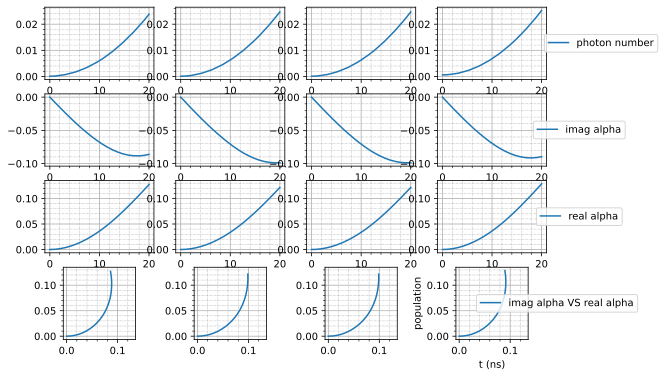

In [4]:

plot_population(results=results,
                qubit_level=ql,
                osc_level=max_ol,
                product_to_dressed=system.product_to_dressed,
                a=system.a,
                w_d=5,
                tlist=results[0].times,
                fourier=1,
                plot_only_pn_alpha=True
                )

In [5]:

results = []
for i in range(4):
    result = run_jax_solve(
        w_d = 7.16475,
        static_hamiltonian= system.diag_dressed_hamiltonian ,  
        initial_state = system.truncate_function(qutip.basis(system.hilbertspace.dimension, i)) , 
        tlist = tlist,
        c_ops = None,
        mode = 'gpu',
        amp = 0.00425,
        driven_operator = system.a_trunc + system.a_trunc.dag(),
        chunk_size = 0.5
        )
    results.append(result)



solving through chunks:   0%|          | 0/40 [00:00<?, ?it/s]

solving through chunks:   0%|          | 0/40 [00:00<?, ?it/s]

solving through chunks:   0%|          | 0/40 [00:00<?, ?it/s]

solving through chunks:   0%|          | 0/40 [00:00<?, ?it/s]

 /home/kai/miniconda3/envs/tensorflow/lib/python3.10/site-packages/matplotlib/cbook.py: 1699ComplexWarning: Casting complex values to real discards the imaginary part
 /home/kai/miniconda3/envs/tensorflow/lib/python3.10/site-packages/matplotlib/cbook.py: 1345

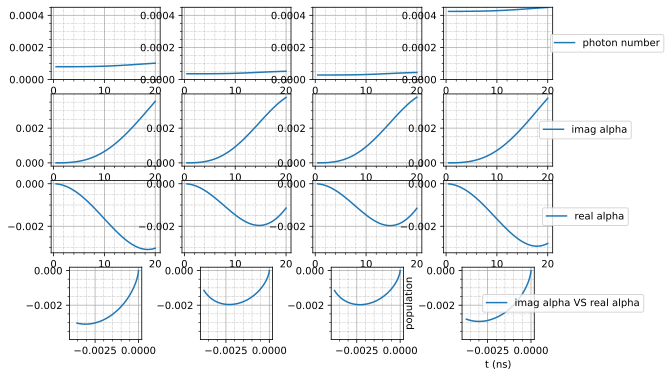

In [6]:


plot_population(results=results,
                qubit_level=ql,
                osc_level=max_ol,
                product_to_dressed=system.product_to_dressed,
                a=system.a_trunc,
                w_d=5,
                tlist=results[0].times,
                fourier=1,
                plot_only_pn_alpha=True
                )